
<br>
Initializing an empty-weighted Unet and training it on the CUB dataset.<br>
Serves as a baseline model for the<br>


In [1]:
import os
from pathlib import Path

root_is_cwd = os.getcwd().endswith("fusionLearning")

if not root_is_cwd:
    os.chdir(Path().resolve().parent.parent)
    print("Changed to root directory")
    root_is_cwd = True
else:
    print("Already in root directory")

print(os.getcwd())

Changed to root directory
C:\Users\GAMER01\codeproj\fusionLearning


In [20]:

import torch
import segmentation_models_pytorch as smp 
import matplotlib.pyplot as plt
from baseModels.dataloaders import create_train_val_test_loaders


In [21]:
MAXEPOCHS = 10
BATCHSIZE = 1
MOMENTUM = 0.99
LEARNING_RATE = 0.01
NUM_CLASSES = 2

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


Model, optimizer, loss definitions -------------------------------------------------------------<br>
vanilla unet, untrained

In [23]:
unet = smp.Unet(
    encoder_name="resnet34",  
    encoder_weights=None,  
    in_channels=3,  
    classes=NUM_CLASSES,
)
unet = unet.to(device)


In [24]:
optimizer = torch.optim.SGD(unet.parameters(),
                           lr=LEARNING_RATE,
                           momentum=MOMENTUM)

In [25]:
lossFunc = torch.nn.CrossEntropyLoss()

Data loaders ------------------------------------------------------------------------------------

In [26]:
# Change to the dir where dataloaders.py is located 
print(os.getcwd())

C:\Users\GAMER01\codeproj\fusionLearning


In [27]:
path_images_folder = os.path.join("CUBdata/CUB_200_2011/images")
path_segmentations_folder = os.path.join("CUBdata/segmentations")

In [28]:
from torchvision import transforms
from baseModels.aug import geoTransforms, photometricTransforms


training_dataloader, validation_dataloader, testing_dataloader = create_train_val_test_loaders(
    image_dir=path_images_folder, 
    segmentation_dir=path_segmentations_folder,
    batch_size=BATCHSIZE,
    gTransforms=geoTransforms,
    pTransforms=photometricTransforms
)

Dataset loaded with 11788 image-segmentation pairs


# Training
- ROC-AUC only computed for validation set.
- No lr scheduler, might be something to implement later
- I think scikitlearn has a faster ROCAUC metrics class

> On an RTX 2060, training takes ~6-7 min / epoch.

__UnetV1__ - 10 epochs, no lr scheduler, unoptimized hyperparams. resnet34 encoder arch.




In [29]:
def visualize_training_process(metrics):
    """Visualize the final training process metrics"""
    plt.figure(figsize=(8, 5))
    plt.plot(metrics['epochs'], metrics['train_loss'], 'bo-', label='Training Loss')
    plt.plot(metrics['epochs'], metrics['val_loss'], 'ro-', label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("outputs/final_training_metrics.png")
    plt.close()


In [38]:


from tqdm import tqdm
import os
import json
from torchmetrics.classification import BinaryAUROC
# !!! TODO: Fix ROC AUC metric calculation in validation phase

def train(modelDir):
    output_dir = modelDir + "outputs"
    os.makedirs(output_dir, exist_ok=True)
    metrics_path = os.path.join(output_dir, "epoch_metrics.json")
    # Initialize metrics file
    with open(metrics_path, 'w') as f:
        json.dump([], f)

    best_val_loss = float('inf')
    val_auc_metric = BinaryAUROC(thresholds=128).to(device)

    for epoch in range(1, MAXEPOCHS + 1):
        # --- Training Phase ---
        unet.train()
        train_loss = 0.0
        for images, masks, _ in tqdm(training_dataloader, desc=f"Epoch {epoch}/{MAXEPOCHS} [Train]", leave=False, ncols=80):
            images = images.to(device)
            masks  = masks.long().to(device)

            optimizer.zero_grad()
            logits = unet(images)
            loss = lossFunc(logits, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
        avg_train_loss = train_loss / len(training_dataloader)
        
        # --- Validation Phase ---
        unet.eval()
        val_loss = 0.0
        val_auc_metric.reset()
        with torch.no_grad():
            for images, masks, _ in tqdm(validation_dataloader, desc=f"Epoch {epoch}/{MAXEPOCHS} [Val]", leave=False, ncols=80):
                images = images.to(device)
                masks  = masks.long().to(device)
                logits = unet(images)
                val_loss += lossFunc(logits, masks.long()).item()

                # Ensure correct shape and type for ROC AUC
                probs = torch.softmax(logits, dim=1)[:, 1].reshape(-1)
                targets = masks.reshape(-1).float()
                val_auc_metric.update(probs, targets)

        avg_val_loss = val_loss / len(validation_dataloader)
        val_auc = val_auc_metric.compute().item()

        # Learning rate -- maybe swap to scheduler for higher convergence
        lr = LEARNING_RATE

        # save to .pth
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(unet.state_dict(), os.path.join(output_dir, 'best_model.pth'))

        # write to jason
        with open(metrics_path, 'r+') as f:
            data = json.load(f)
            data.append({
                'epoch': epoch,
                'train_loss': avg_train_loss,
                'val_loss': avg_val_loss,
                'val_auc': val_auc,
                'lr': lr
            })
            f.seek(0)
            json.dump(data, f, indent=2)
            f.truncate()

        print(f"Epoch {epoch:2d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} "
              f"| Val AUC: {val_auc:.4f} | LR: {lr:.6f}")

    print(f"Training complete. Metrics written to {metrics_path}")


In [40]:

def test(modelDir):
    unet.eval()
    tloss = 0.0

    with torch.no_grad():
        for image, segmentation_mask, _ in tqdm(testing_dataloader, desc=f"[TEST]", leave=False, ncols=80):
            image = image.to(device)
            segmentation_mask = segmentation_mask.long().to(device)

            logits = unet(image)
            tloss += lossFunc(logits, segmentation_mask.long()).item()

    avg_test_loss = tloss / len(testing_dataloader)

    test_metrics = {
        'test_loss': avg_test_loss,
    }
    with open(modelDir + 'outputs/test_metrics.json', 'w') as f:
        json.dump(test_metrics, f)

    print(f"Test: Loss={avg_test_loss:.4f}")
    return test_metrics

In [42]:
import matplotlib.pyplot as plt
import json

def plot_metrics(modelDir):
    with open(modelDir + "outputs/epoch_metrics.json", 'r') as f:
        data = json.load(f)
    epochs = [d['epoch'] for d in data]
    train_loss = [d['train_loss'] for d in data]
    val_loss = [d['val_loss'] for d in data]
    val_auc = [d['val_auc'] for d in data]
    lr = [d['lr'] for d in data]
    plt.figure(figsize=(12, 8))
    plt.subplot(2,1,1)
    plt.plot(epochs, train_loss, 'b-', label='Train Loss')
    plt.plot(epochs, val_loss, 'r-', label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.subplot(2,1,2)
    plt.plot(epochs, val_auc, 'r-', label='Validation ROC AUC')
    plt.xlabel('Epoch')
    plt.ylabel('Validation ROC AUC')
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(modelDir + "outputs/final_training_metrics.png")
    plt.show()

In [43]:
if __name__ == "__main__":

    modelDir = "baseModels/Unet_resnet34/"
    # Create outputs directory if it doesn't exist
    os.makedirs(modelDir + "outputs", exist_ok=True)
    
    if os.path.exists(modelDir + "outputs/best_model.pth"):
        print("Model already trained. To retrain, delete the 'outputs/best_model.pth' file.\n Going ahead with testing...")

        # Load best model

        unet = smp.Unet(
            encoder_name="resnet34",  
            encoder_weights=None,  
            in_channels=3,  
            classes=NUM_CLASSES,
        )
        unet.load_state_dict(torch.load(modelDir + "outputs/best_model.pth"))
        unet.to(device)

        test_metrics = test(modelDir)
        print("\nTesting completed successfully.")
        plot_metrics(modelDir)
    else:
        if device.type == "cuda":
            print("Starting training process...")
            train(modelDir)
            print("\nStarting testing process...")
            test_metrics = test(modelDir)
            print("\nTraining and testing completed successfully.")
            print("\t * Results and visualizations saved in the 'outputs' directory. * ")

            plot_metrics(modelDir)

        else:
            print("No GPU available, exiting...")

Model already trained. To retrain, delete the 'outputs/best_model.pth' file.
 Going ahead with testing...


RuntimeError: only batches of spatial targets supported (3D tensors) but got targets of size: : [1, 1, 512, 448]

In [44]:
import random

def inference_from_paths(modelDir, testing_dataloader, n=5):
    # limit to 50 samples
    """
    Samples n random datapoints from the test set using the underlying dataset's image paths,
    loads and visualizes both the true and predicted segmentation masks.
    """
    # Try to access the dataset object and its image paths
    dataset = testing_dataloader.dataset
    if hasattr(dataset, 'dataset'):
        # This is a Subset, get the original dataset
        base_dataset = dataset.dataset
        indices = dataset.indices
        image_paths = [base_dataset.image_paths[i] for i in indices]
    else:
        image_paths = dataset.image_paths

    total_samples = len(image_paths)
    n = min(n, 50)                                          
    indices = random.sample(range(total_samples), n)

    unet = smp.Unet(
        encoder_name="resnet34",  
        encoder_weights=None,  
        in_channels=3,  
        classes=NUM_CLASSES,
    ).to(device)
    unet.load_state_dict(torch.load(modelDir + "outputs/best_model.pth", map_location=device))
    unet.eval()

    plt.figure(figsize=(6, n * 3))
    for i, idx in enumerate(indices):
        # Get sample from dataset by index
        image, true_mask, _ = dataset[idx]
        image_input = image.to(device).unsqueeze(0)
        true_mask_np = true_mask.cpu().numpy()

        with torch.no_grad():
            logits = unet(image_input)
            pred_mask = torch.argmax(logits, dim=1)[0].cpu().numpy()

        plt.subplot(n, 3, i * 3 + 1)
        plt.imshow(image.cpu().permute(1, 2, 0))
        plt.title(f"Sample {i+1}: Image")
        plt.axis('off')

        plt.subplot(n, 3, i * 3 + 2)
        plt.imshow(true_mask_np, cmap='gray')
        plt.title("True Mask")
        plt.axis('off')

        plt.subplot(n, 3, i * 3 + 3)
        plt.imshow(pred_mask, cmap='gray')
        plt.title("Predicted Mask")
        plt.axis('off')

    plt.tight_layout()
    plt.savefig(modelDir + "outputs/inference.png")
    plt.show()

    plt.close()


TypeError: Invalid shape (1, 512, 352) for image data

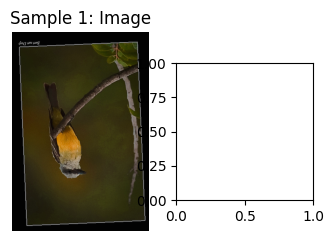

In [45]:
inference_from_paths(modelDir="baseModels/Unet_resnet34/", testing_dataloader=testing_dataloader, n=5)

In [46]:

from baseModels.dataloaders import generateSegmentationMasks

unet = smp.Unet(
    encoder_name="resnet34",  
    encoder_weights=None,  
    in_channels=3,  
    classes=NUM_CLASSES,
).to(device)



generateSegmentationMasks(model=unet, 
                            model_name="Unet_resnet34", 
                            model_weights_path="baseModels/Unet_resnet34/outputs/best_model.pth", 
                            image_dir="CUBdata/CUB_200_2011/images", 
                            segmentation_dir="CUBdata/segmentations", 
                            batch_size=1,
                            save_dir="images/segmentations")

                            



Using device: cuda
Dataset loaded with 11788 image-segmentation pairs


KeyboardInterrupt: 